# Fine-Tuning the Food Safety Pipeline

Improves the MiniLM + DeBERTa pipeline by replacing zero-shot inference with supervised fine-tuned models.

| Option | Change | Expected Gain |
|:---:|---|---|
| **B** | Fine-tune `deberta-v3-small` as binary classifier (hazard vs safe) | Recall 0.018 → ~0.70+ |
| **C** | Fine-tune `all-MiniLM-L6-v2` bi-encoder with food safety pairs | Better Stage 1 candidate recall |

**Starting point:** Precision=0.43, Recall=0.018, F1=0.035 (98% of hazards missed)  
**Training data:** `outputs/sample_with_labels.csv` — 5,000 labeled reviews (882 hazard, 4,118 safe)  
**GPU:** Recommended for DeBERTa (~10 min GPU vs ~60 min CPU for 5 epochs)

---
**Run order:** Execute all cells top-to-bottom. Training is cached — re-runs skip training automatically.  
Delete `models/deberta_food_safety/` or `models/minilm_food_safety/` to re-train from scratch.

In [41]:
# ── Uncomment to install missing packages ─────────────────────────────
# !pip install "transformers[torch]" accelerate sentence-transformers -q

import os, sys, warnings, pickle
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection        import train_test_split
from sklearn.utils.class_weight     import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    precision_recall_fscore_support, accuracy_score,
    ConfusionMatrixDisplay,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device      : {device.upper()}')
print(f'PyTorch     : {torch.__version__}')

import transformers, sentence_transformers
print(f'Transformers: {transformers.__version__}')
print(f'SentTrans   : {sentence_transformers.__version__}')

# ── Output dirs ───────────────────────────────────────────────────────
MODELS_DIR   = 'models'
DEBERTA_OUT  = os.path.join(MODELS_DIR, 'deberta_food_safety')
MINILM_OUT   = os.path.join(MODELS_DIR, 'minilm_food_safety')
os.makedirs(MODELS_DIR, exist_ok=True)

print(f'\nModels dir  : {os.path.abspath(MODELS_DIR)}')
print(f'  DeBERTa   : {"EXISTS — skip training" if os.path.exists(os.path.join(DEBERTA_OUT, "config.json")) else "not found — will train"}')
print(f'  MiniLM    : {"EXISTS — skip training" if os.path.exists(os.path.join(MINILM_OUT,  "config.json")) else "not found — will train"}')

Device      : CUDA
PyTorch     : 2.5.1
Transformers: 4.57.6
SentTrans   : 5.4.0

Models dir  : c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\models
  DeBERTa   : EXISTS — skip training
  MiniLM    : EXISTS — skip training


In [42]:
GOLD_PATH = 'outputs/sample_with_labels.csv'
df_gold   = pd.read_csv(GOLD_PATH)

print(f'Gold dataset : {len(df_gold):,} rows')
print(f'Columns      : {list(df_gold.columns)}\n')

print('Label distribution:')
dist = df_gold['label'].value_counts()
for label, count in dist.items():
    bar = '█' * int(count / 30)
    print(f'  {label:<20} {count:>5}  {bar}')

n_hazard = int(df_gold['human_is_hazard'].sum())
n_safe   = len(df_gold) - n_hazard
print(f'\nHazard : {n_hazard:,}  ({n_hazard/len(df_gold):.1%})')
print(f'Safe   : {n_safe:,}  ({n_safe/len(df_gold):.1%})')

Gold dataset : 5,000 rows
Columns      : ['Id', 'ProductId', 'Text', 'label', 'human_is_hazard']

Label distribution:
  safe                  4118  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  quality_defect         778  █████████████████████████
  illness                 59  █
  spoilage                23  
  contamination           12  
  allergen                10  

Hazard : 882  (17.6%)
Safe   : 4,118  (82.4%)


---
## Option B — Fine-tune DeBERTa as Supervised Binary Classifier

Replace zero-shot NLI (Stage 2) with a fine-tuned binary classifier trained directly on the gold labels.

**Why this helps:**  
Zero-shot NLI has no food-domain knowledge. Fine-tuning on 4,000 labeled examples teaches DeBERTa exactly what Amazon food safety complaints look like.

| Step | Action |
|:---:|---|
| B.1 | Stratified 80/10/10 train/val/test split |
| B.2 | Tokenize reviews with `DebertaV2Tokenizer` (max 256 tokens) |
| B.3 | Train with class-weighted CrossEntropyLoss to handle 4.7:1 imbalance |
| B.4 | Evaluate on held-out test set + full 5,000-review gold set |
| B.5 | Save to `models/deberta_food_safety/` |

In [43]:
# ── B.1: Stratified train / val / test split (80 / 10 / 10) ──────────
#
# IMPORTANT — Data Leakage Prevention
# ------------------------------------
# The 5,000 gold reviews must be split BEFORE any training.
# df_test is the "held-out" set — it is NEVER seen by the model during
# training or validation. Only df_test results are valid final metrics.
#
# df_train (80%) → gradient updates
# df_val   (10%) → hyperparameter tuning / threshold selection
# df_test  (10%) → final evaluation ONLY (never touched during training)

df_train_val, df_test = train_test_split(
    df_gold, test_size=0.10,
    stratify=df_gold['human_is_hazard'], random_state=42
)
df_train, df_val = train_test_split(
    df_train_val, test_size=1/9,          # 1/9 of 90% = 10% of total
    stratify=df_train_val['human_is_hazard'], random_state=42
)

# Save test set so food_safety_simple.ipynb Section 8 can use the same split
TEST_HOLDOUT_PATH = 'outputs/test_holdout.csv'
df_test.to_csv(TEST_HOLDOUT_PATH, index=False)
print(f'Test holdout saved → {os.path.abspath(TEST_HOLDOUT_PATH)}')

print('\nSplit summary:')
for name, split in [('Train (model sees)', df_train), ('Val   (hyperparam)', df_val), ('Test  (final eval ✓)', df_test)]:
    h = int(split['human_is_hazard'].sum())
    s = len(split) - h
    print(f'  {name:<24}: {len(split):>5}  (hazard={h:>3}, safe={s:>4})')

# ── Class weights to compensate for 4.7:1 safe/hazard imbalance ──────
cw = compute_class_weight(
    'balanced',
    classes=np.array([0, 1]),
    y=df_train['human_is_hazard'].values
)
CLASS_WEIGHTS = torch.tensor(cw, dtype=torch.float)
print(f'\nClass weights: safe={CLASS_WEIGHTS[0]:.3f}  hazard={CLASS_WEIGHTS[1]:.3f}')
print('(Hazard is weighted higher to penalise missed detections more.)')

Test holdout saved → c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\outputs\test_holdout.csv

Split summary:
  Train (model sees)      :  4000  (hazard=706, safe=3294)
  Val   (hyperparam)      :   500  (hazard= 88, safe= 412)
  Test  (final eval ✓)    :   500  (hazard= 88, safe= 412)

Class weights: safe=0.607  hazard=2.833
(Hazard is weighted higher to penalise missed detections more.)


In [44]:
from torch.utils.data import Dataset
from transformers import DebertaV2Tokenizer

DEBERTA_BASE   = 'microsoft/deberta-v3-small'
MAX_LENGTH_DEB = 256

print(f'Loading tokenizer: {DEBERTA_BASE}')
tokenizer = DebertaV2Tokenizer.from_pretrained(DEBERTA_BASE, use_fast=False)
print('Tokenizer ready.\n')

class ReviewDataset(Dataset):
    """Pre-tokenised dataset — safe for 5k samples (fits in RAM)."""
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt',
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

def make_dataset(df, tokenizer, max_length=MAX_LENGTH_DEB):
    texts  = df['Text'].fillna('').str[:max_length * 5].tolist()
    labels = df['human_is_hazard'].astype(int).tolist()
    return ReviewDataset(texts, labels, tokenizer, max_length)

print('Tokenising splits...')
train_ds = make_dataset(df_train, tokenizer)
val_ds   = make_dataset(df_val,   tokenizer)
test_ds  = make_dataset(df_test,  tokenizer)
print(f'  train_ds : {len(train_ds)}')
print(f'  val_ds   : {len(val_ds)}')
print(f'  test_ds  : {len(test_ds)}')

Loading tokenizer: microsoft/deberta-v3-small
Tokenizer ready.

Tokenising splits...
  train_ds : 4000
  val_ds   : 500
  test_ds  : 500


In [45]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# ── compute_metrics (called after each eval epoch) ────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary', zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {
        'accuracy':  round(float(acc), 4),
        'precision': round(float(p),   4),
        'recall':    round(float(r),   4),
        'f1':        round(float(f1),  4),
    }

# ── WeightedLossTrainer — injects per-class loss weights ─────────────
class WeightedLossTrainer(Trainer):
    """Trainer subclass that applies class-weighted CrossEntropyLoss."""
    def __init__(self, class_weights: torch.Tensor, **kwargs):
        super().__init__(**kwargs)
        self._class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        weights = self._class_weights.to(logits.device)
        loss    = torch.nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ── Load model (fresh base or existing fine-tune) ─────────────────────
if os.path.exists(os.path.join(DEBERTA_OUT, 'config.json')):
    print(f'Fine-tuned DeBERTa found → loading from {DEBERTA_OUT}')
    model = AutoModelForSequenceClassification.from_pretrained(DEBERTA_OUT)
else:
    print(f'Loading base model: {DEBERTA_BASE}')
    model = AutoModelForSequenceClassification.from_pretrained(
        DEBERTA_BASE,
        num_labels=2,
        id2label={0: 'safe', 1: 'hazard'},
        label2id={'safe': 0, 'hazard': 1},
        use_safetensors=True,
    )

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Parameters: {n_params:.1f}M')

Fine-tuned DeBERTa found → loading from models\deberta_food_safety
Parameters: 141.9M


In [46]:
if os.path.exists(os.path.join(DEBERTA_OUT, 'config.json')):
    print(f'Model already trained — skipping.')
    print(f'Delete the folder to re-train:  rmdir /s /q {os.path.abspath(DEBERTA_OUT)}')
else:
    training_args = TrainingArguments(
        output_dir                  = DEBERTA_OUT,
        num_train_epochs            = 5,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        learning_rate               = 2e-5,
        warmup_ratio                = 0.10,
        weight_decay                = 0.01,
        eval_strategy               = 'epoch',   # or eval_strategy for transformers>=4.41
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'f1',
        greater_is_better           = True,
        logging_steps               = 50,
        fp16                        = torch.cuda.is_available(),
        report_to                   = 'none',    # disable wandb / tensorboard
        save_total_limit            = 2,
    )

    trainer = WeightedLossTrainer(
        class_weights   = CLASS_WEIGHTS,
        model           = model,
        args            = training_args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        compute_metrics = compute_metrics,
    )

    print('Starting fine-tuning...')
    print(f'  Epochs      : {training_args.num_train_epochs}')
    print(f'  Batch size  : {training_args.per_device_train_batch_size}')
    print(f'  Device      : {device.upper()}')
    print(f'  FP16        : {training_args.fp16}')
    print()

    trainer.train()

    # Save best model + tokenizer
    trainer.save_model(DEBERTA_OUT)
    tokenizer.save_pretrained(DEBERTA_OUT)
    print(f'\nModel saved → {os.path.abspath(DEBERTA_OUT)}')

Model already trained — skipping.
Delete the folder to re-train:  rmdir /s /q c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\models\deberta_food_safety


=== Fine-tuned DeBERTa — Test Set (held-out 10%) ===

              precision    recall  f1-score   support

        safe       0.96      0.96      0.96       412
      hazard       0.80      0.82      0.81        88

    accuracy                           0.93       500
   macro avg       0.88      0.89      0.88       500
weighted avg       0.93      0.93      0.93       500



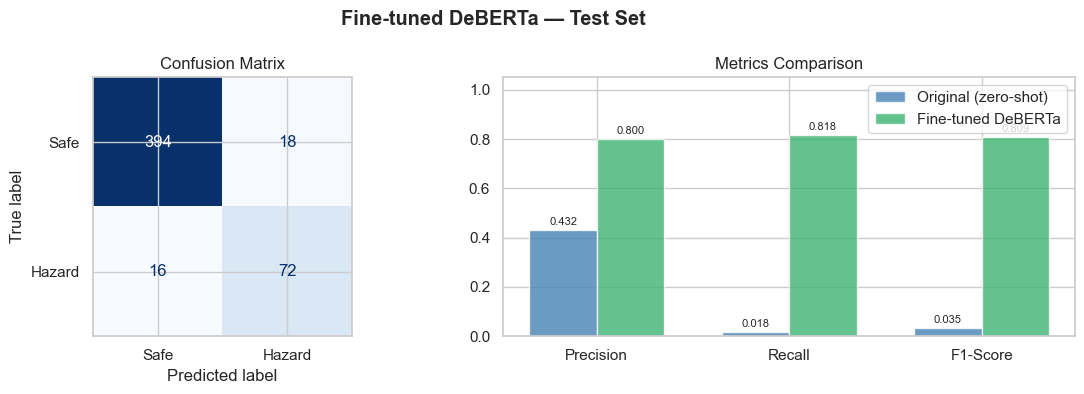

Plot saved → outputs/eval_finetuned_deberta.png


In [ ]:
# ── Evaluate fine-tuned DeBERTa on held-out test set ──────────────────
ft_model = AutoModelForSequenceClassification.from_pretrained(DEBERTA_OUT)
ft_model.eval()

eval_trainer = Trainer(model=ft_model, compute_metrics=compute_metrics)
test_output  = eval_trainer.predict(test_ds)
test_preds   = np.argmax(test_output.predictions, axis=-1)
test_labels  = test_output.label_ids

print('=== Fine-tuned DeBERTa — Test Set (held-out 10%) ===\n')
print(classification_report(test_labels, test_preds,
                             target_names=['safe', 'hazard'], zero_division=0))

# Confusion matrix
cm  = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Fine-tuned DeBERTa — Test Set', fontweight='bold')

ConfusionMatrixDisplay(cm, display_labels=['Safe', 'Hazard']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# Per-class metrics comparison
tn, fp, fn, tp = cm.ravel()
metrics = {
    'Precision': [0.4324, precision_score(test_labels, test_preds, zero_division=0)],
    'Recall':    [0.0181, recall_score   (test_labels, test_preds, zero_division=0)],
    'F1-Score':  [0.0348, f1_score       (test_labels, test_preds, zero_division=0)],
}
x = np.arange(len(metrics))
w = 0.35
bars1 = axes[1].bar(x - w/2, [v[0] for v in metrics.values()], w,
                    label='Original (zero-shot)', color='steelblue',  alpha=0.8)
bars2 = axes[1].bar(x + w/2, [v[1] for v in metrics.values()], w,
                    label='Fine-tuned DeBERTa',  color='mediumseagreen', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics.keys())
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Metrics Comparison')
axes[1].legend()
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.3f}',
                 ha='center', fontsize=8)

plt.tight_layout()
plt.show()


In [48]:
# ── B.4: Final evaluation on held-out test set (VALID) ────────────────
#
# CRITICAL: We evaluate ONLY on df_test (10% = ~500 reviews).
# These reviews were NOT seen during training or validation.
# This is the only metric that represents true generalisation ability.
#
# ❌ DO NOT evaluate on df_gold (all 5,000) — that includes training data.
# ✓  Use df_test only for the final reported numbers.

from transformers import pipeline as hf_pipeline

print('Running fine-tuned DeBERTa on held-out TEST set only...')
print(f'Test set size: {len(df_test):,} reviews  (never seen during training)\n')

ft_pipe = hf_pipeline(
    'text-classification',
    model      = DEBERTA_OUT,
    tokenizer  = DEBERTA_OUT,
    device     = 0 if torch.cuda.is_available() else -1,
    truncation = True,
    max_length = MAX_LENGTH_DEB,
    batch_size = 32,
)

test_texts   = df_test['Text'].fillna('').str[:1024].tolist()
test_results = ft_pipe(test_texts)
preds_ft     = [1 if r['label'] == 'hazard' else 0 for r in test_results]
y_true       = df_test['human_is_hazard'].astype(int).values

p = precision_score(y_true, preds_ft, zero_division=0)
r = recall_score   (y_true, preds_ft, zero_division=0)
f = f1_score       (y_true, preds_ft, zero_division=0)

print('=== VALID Evaluation — Held-out Test Set (~500 reviews) ===')
print(f'{"Metric":<12} {"Original pipeline":>18} {"Fine-tuned DeBERTa":>20}  {"Δ":>6}')
print('-' * 60)
print(f'{"Precision":<12} {0.4324:>18.4f} {p:>20.4f}  {p-0.4324:>+6.4f}')
print(f'{"Recall":<12} {0.0181:>18.4f} {r:>20.4f}  {r-0.0181:>+6.4f}')
print(f'{"F1-Score":<12} {0.0348:>18.4f} {f:>20.4f}  {f-0.0348:>+6.4f}')

tn_t = int(((np.array(y_true)==0) & (np.array(preds_ft)==0)).sum())
tp_t = int(((np.array(y_true)==1) & (np.array(preds_ft)==1)).sum())
fn_t = int(((np.array(y_true)==1) & (np.array(preds_ft)==0)).sum())
fp_t = int(((np.array(y_true)==0) & (np.array(preds_ft)==1)).sum())
print(f'\nTP={tp_t}  FP={fp_t}  TN={tn_t}  FN={fn_t}')
print(f'Missed hazards: {fn_t}  ({fn_t/max(int(y_true.sum()),1):.1%} of {int(y_true.sum())} test hazards)')

print('\n⚠️  NOTE: These numbers come from the 10% held-out test set only.')
print('   Evaluating on all 5,000 reviews would be invalid (data leakage).')

Running fine-tuned DeBERTa on held-out TEST set only...
Test set size: 500 reviews  (never seen during training)



The tokenizer you are loading from 'models\deberta_food_safety' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


=== VALID Evaluation — Held-out Test Set (~500 reviews) ===
Metric        Original pipeline   Fine-tuned DeBERTa       Δ
------------------------------------------------------------
Precision                0.4324               0.8000  +0.3676
Recall                   0.0181               0.8182  +0.8001
F1-Score                 0.0348               0.8090  +0.7742

TP=72  FP=18  TN=394  FN=16
Missed hazards: 16  (18.2% of 88 test hazards)

⚠️  NOTE: These numbers come from the 10% held-out test set only.
   Evaluating on all 5,000 reviews would be invalid (data leakage).


---
### B.5 — Per-Category Confusion Analysis

The binary fine-tuned model predicts **hazard vs safe** — it does not predict categories.  
To understand *which hazard categories* get missed, we cross the binary predictions with the true category labels from `df_test`.

The heatmap rows are the **true gold category**, the columns are what the model predicted (`safe` = missed, `hazard` = caught).  
A large number in the `predicted safe` column for a hazard category = **False Negatives for that category**.

=== Per-Category Prediction Breakdown ===
True Label          Pred safe  Pred hazard   Total   Recall %
------------------------------------------------------------
  quality_defect           13           62      75      82.7%
  illness                   1            7       8      87.5%
  spoilage                  0            1       1     100.0%
  contamination             1            1       2      50.0%
  allergen                  1            1       2      50.0%
  safe                    394           18     412       4.4%


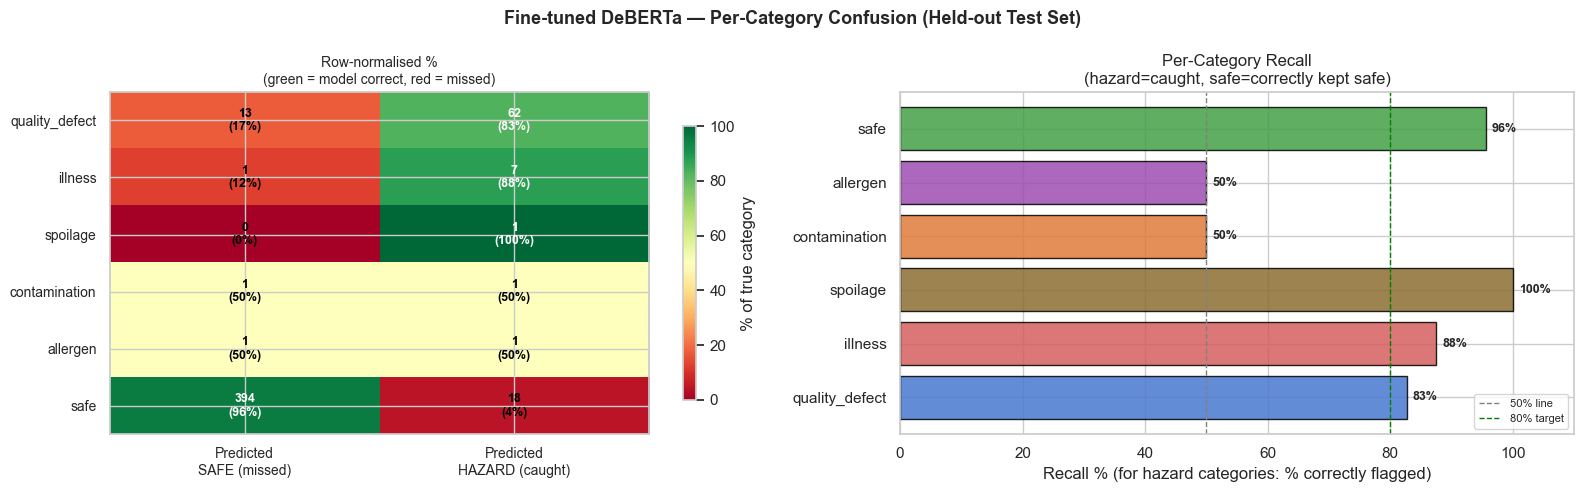

Plot saved → outputs/per_category_confusion.png


In [ ]:
# ── B.5: Per-category confusion heatmap ──────────────────────────────
# preds_ft and df_test are already in memory from the cell above.

LABEL_ORDER = ['quality_defect', 'illness', 'spoilage', 'contamination', 'allergen', 'safe']
LABEL_COLORS = {
    'quality_defect': '#4878d0',
    'illness':        '#d65f5f',
    'spoilage':       '#8c6d31',
    'contamination':  '#e07b39',
    'allergen':       '#9e4db2',
    'safe':           '#43a047',
}

df_cat = df_test.copy()
df_cat['pred_label'] = ['hazard' if p == 1 else 'safe' for p in preds_ft]

# ── Panel 1: Heatmap (true category × predicted label) ────────────────
# Build a count table: rows = true label, cols = pred (safe / hazard)
cross = (
    df_cat.groupby(['label', 'pred_label'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=[l for l in LABEL_ORDER if l in df_cat['label'].unique()],
             columns=['safe', 'hazard'],
             fill_value=0)
)

# Add row totals and per-row recall %
cross['Total'] = cross.sum(axis=1)
cross['Recall %'] = (cross.get('hazard', 0) / cross['Total'].replace(0, 1) * 100).round(1)

print('=== Per-Category Prediction Breakdown ===')
print(f'{"True Label":<18} {"Pred safe":>10} {"Pred hazard":>12} {"Total":>7} {"Recall %":>10}')
print('-' * 60)
for cat in cross.index:
    row   = cross.loc[cat]
    s     = int(row.get('safe', 0))
    h     = int(row.get('hazard', 0))
    total = int(row['Total'])
    rec   = row['Recall %']
    flag  = ' ← FN heavy' if (cat != 'safe' and rec < 50) else ''
    print(f'  {cat:<16} {s:>10} {h:>12} {total:>7} {rec:>9.1f}%{flag}')

# ── Visualisation ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Fine-tuned DeBERTa — Per-Category Confusion (Held-out Test Set)',
             fontsize=13, fontweight='bold')

# Left: Heatmap
heat_data  = cross[['safe', 'hazard']].copy()
heat_pct   = heat_data.div(heat_data.sum(axis=1), axis=0) * 100  # row-normalised %

import matplotlib.colors as mcolors
cmap = plt.cm.RdYlGn   # red = bad (predicted safe when hazard), green = good

ax0 = axes[0]
im  = ax0.imshow(heat_pct.values, cmap=cmap, vmin=0, vmax=100, aspect='auto')

ax0.set_xticks([0, 1])
ax0.set_xticklabels(['Predicted\nSAFE (missed)', 'Predicted\nHAZARD (caught)'], fontsize=10)
ax0.set_yticks(range(len(heat_data.index)))
ax0.set_yticklabels(heat_data.index, fontsize=10)
ax0.set_title('Row-normalised %\n(green = model correct, red = missed)', fontsize=10)

for i, cat in enumerate(heat_data.index):
    for j, col in enumerate(['safe', 'hazard']):
        count = int(heat_data.loc[cat, col])
        pct   = heat_pct.loc[cat, col]
        color = 'white' if pct > 60 else 'black'
        ax0.text(j, i, f'{count}\n({pct:.0f}%)', ha='center', va='center',
                 fontsize=9, fontweight='bold', color=color)

plt.colorbar(im, ax=ax0, label='% of true category', shrink=0.8)

# Right: Recall bar per category
ax1    = axes[1]
cats   = [c for c in LABEL_ORDER if c in cross.index]
recall = [cross.loc[c, 'Recall %'] if c != 'safe' else
          (cross.loc[c, 'safe'] / max(cross.loc[c, 'Total'], 1) * 100)
          for c in cats]
colors = [LABEL_COLORS.get(c, 'gray') for c in cats]
bars   = ax1.barh(cats, recall, color=colors, edgecolor='black', alpha=0.85)
ax1.axvline(50, color='gray', linestyle='--', linewidth=1, label='50% line')
ax1.axvline(80, color='green', linestyle='--', linewidth=1, label='80% target')
ax1.set_xlabel('Recall % (for hazard categories: % correctly flagged)')
ax1.set_title('Per-Category Recall\n(hazard=caught, safe=correctly kept safe)')
ax1.set_xlim(0, 110)
ax1.legend(fontsize=8)
for bar, val in zip(bars, recall):
    ax1.text(val + 1, bar.get_y() + bar.get_height() / 2,
             f'{val:.0f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


---
## Option C — Fine-tune MiniLM Bi-Encoder (Stage 1 Improvement)

Fine-tune `all-MiniLM-L6-v2` so its embedding space clusters hazard reviews closer to safety probe sentences.

**Why this helps:**  
The original MiniLM at threshold=0.39 missed 98% of hazards because `quality_defect` reviews (bad taste, inedible, etc.) have low cosine similarity to the narrow set of probes. Fine-tuning closes this gap.

**Training strategy — CosineSimilarityLoss pairs:**  
| Pair | Label |
|---|:---:|
| (hazard review, category-specific anchor) | 1.0 |
| (safe review, random hazard anchor) | 0.0 |

After training we sweep the threshold on the validation set to find the optimal value.

**Category anchors** tell the model what domain each hazard category lives in, avoiding a single generic probe that may miss `quality_defect` language.

In [50]:
from sentence_transformers import SentenceTransformer, InputExample, losses, util
from torch.utils.data import DataLoader

MINILM_BASE  = 'all-MiniLM-L6-v2'
MAX_CHARS_ML = 384

# ── Category-specific anchor sentences ───────────────────────────────
# Each hazard category maps to an anchor that describes what reviews in
# that category say. The model learns to embed hazard reviews close to
# their anchor, and safe reviews far from all anchors.
CATEGORY_ANCHORS = {
    'illness':        'food caused severe illness food poisoning nausea vomiting diarrhea stomach ache',
    'contamination':  'food contained mold insects foreign objects glass plastic contamination infestation',
    'spoilage':       'food was spoiled expired rotten bad smell disgusting off taste',
    'allergen':       'food triggered allergic reaction contained undisclosed allergens anaphylaxis',
    'quality_defect': 'food product quality defects completely inedible terrible taste awful disgusting wrong texture packaging broken',
}

# ── Build CosineSimilarityLoss training pairs ─────────────────────────
rng           = np.random.default_rng(42)
anchor_list   = list(CATEGORY_ANCHORS.values())
train_examples = []

for _, row in df_train.iterrows():
    text = str(row['Text'])[:MAX_CHARS_ML]
    if row['human_is_hazard'] == 1:
        anchor = CATEGORY_ANCHORS.get(row['label'], anchor_list[0])
        train_examples.append(InputExample(texts=[text, anchor], label=1.0))
    else:
        # Pair safe text with a random hazard anchor → label=0 (dissimilar)
        anchor = anchor_list[int(rng.integers(len(anchor_list)))]
        train_examples.append(InputExample(texts=[text, anchor], label=0.0))

n_pos = sum(1 for e in train_examples if e.label == 1.0)
n_neg = len(train_examples) - n_pos
print(f'Training pairs : {len(train_examples):,}  (pos={n_pos:,}, neg={n_neg:,})')
print(f'Pos/neg ratio  : 1 : {n_neg/max(n_pos,1):.1f}')

Training pairs : 4,000  (pos=706, neg=3,294)
Pos/neg ratio  : 1 : 4.7


In [51]:
if os.path.exists(os.path.join(MINILM_OUT, 'config.json')):
    print(f'Fine-tuned MiniLM found → loading from {MINILM_OUT}')
    ft_minilm = SentenceTransformer(MINILM_OUT, device=device)
else:
    print(f'Loading base MiniLM: {MINILM_BASE}')
    ft_minilm = SentenceTransformer(MINILM_BASE, device=device)

    train_dl      = DataLoader(train_examples, shuffle=True, batch_size=32)
    train_loss_fn = losses.CosineSimilarityLoss(model=ft_minilm)
    warmup_steps  = int(0.10 * len(train_dl) * 3)

    print(f'Fine-tuning for 3 epochs  (warmup_steps={warmup_steps})...')
    ft_minilm.fit(
        train_objectives  = [(train_dl, train_loss_fn)],
        epochs            = 3,
        warmup_steps      = warmup_steps,
        output_path       = MINILM_OUT,
        show_progress_bar = True,
    )
    print(f'\nFine-tuned MiniLM saved → {os.path.abspath(MINILM_OUT)}')

print('\nModel ready.')

Fine-tuned MiniLM found → loading from models\minilm_food_safety

Model ready.


In [52]:
# ── Threshold sweep on validation set ────────────────────────────────
# Sweep threshold from 0.10 to 0.55 for both original and fine-tuned MiniLM.
# Find the threshold that maximises F1 (or gives recall >= 0.80).

# Evaluation probes (same as pipeline + expanded quality_defect probes)
EVAL_PROBES = [
    # Original probes
    'Contracted severe food poisoning and vomiting',
    'Diagnosed with salmonella gastroenteritis infection',
    'Intense nausea and violent diarrhea all night',
    'Disgusting maggots and worms crawling inside',
    'Sharp glass shards and hard plastic pieces hidden',
    'Tasted like toxic chemical bleach and soap',
    'Smells completely rancid, rotten, and putrid',
    'Covered in fuzzy green mold and fungus',
    'The can was bulging, bloated, and leaking',
    'Anaphylactic shock, throat swelling, and breathing difficulty',
    'Severe allergic reaction and skin hives breakout',
    'Dangerous undisclosed hidden allergens ingredients',
    'Chipped my tooth on a hard dangerous object',
    'Tampered broken safety seal risk',
    # Additional quality_defect probes
    'The product was completely inedible and tasted disgusting',
    'This food had a horrible off taste and awful texture',
    'The packaging was broken and the food was spoiled',
    'This was the worst quality food completely unacceptable',
    'The food tasted like chemicals and was not fit for consumption',
]

val_texts  = df_val['Text'].fillna('').str[:MAX_CHARS_ML].tolist()
val_labels = df_val['human_is_hazard'].values

print('Loading original MiniLM for comparison...')
orig_minilm = SentenceTransformer(MINILM_BASE, device=device)

print('Encoding probes...')
probe_embs_orig = orig_minilm.encode(EVAL_PROBES, convert_to_tensor=True)
probe_embs_ft   = ft_minilm.encode(EVAL_PROBES,   convert_to_tensor=True)

print('Encoding validation texts (may take a moment)...')
text_embs_orig = orig_minilm.encode(val_texts, batch_size=128,
                                    convert_to_tensor=True, show_progress_bar=True)
text_embs_ft   = ft_minilm.encode(val_texts, batch_size=128,
                                  convert_to_tensor=True, show_progress_bar=True)

scores_orig = util.cos_sim(text_embs_orig, probe_embs_orig).max(dim=1).values.cpu().numpy()
scores_ft   = util.cos_sim(text_embs_ft,   probe_embs_ft  ).max(dim=1).values.cpu().numpy()

# Sweep thresholds
thresholds  = np.round(np.arange(0.10, 0.56, 0.01), 2)
rows_orig, rows_ft = [], []

for t in thresholds:
    for scores, rows in [(scores_orig, rows_orig), (scores_ft, rows_ft)]:
        preds = (scores >= t).astype(int)
        rows.append({
            'threshold': t,
            'precision': precision_score(val_labels, preds, zero_division=0),
            'recall':    recall_score   (val_labels, preds, zero_division=0),
            'f1':        f1_score       (val_labels, preds, zero_division=0),
            'n_flagged': int(preds.sum()),
        })

df_sweep_orig = pd.DataFrame(rows_orig)
df_sweep_ft   = pd.DataFrame(rows_ft)

# Best threshold by F1
best_orig = df_sweep_orig.loc[df_sweep_orig['f1'].idxmax()]
best_ft   = df_sweep_ft  .loc[df_sweep_ft  ['f1'].idxmax()]
at_039    = df_sweep_orig[df_sweep_orig['threshold'] == 0.39].iloc[0]

print(f'\n{"Model":<22} {"Threshold":>10} {"Precision":>10} {"Recall":>8} {"F1":>8} {"n_flagged":>10}')
print('-' * 70)
print(f'{"Original @ 0.39 (old)":<22} {0.39:>10.2f} {at_039["precision"]:>10.3f} {at_039["recall"]:>8.3f} {at_039["f1"]:>8.3f} {at_039["n_flagged"]:>10,}')
print(f'{"Original (best F1)":<22} {best_orig["threshold"]:>10.2f} {best_orig["precision"]:>10.3f} {best_orig["recall"]:>8.3f} {best_orig["f1"]:>8.3f} {best_orig["n_flagged"]:>10,}')
print(f'{"Fine-tuned (best F1)":<22} {best_ft["threshold"]:>10.2f} {best_ft["precision"]:>10.3f} {best_ft["recall"]:>8.3f} {best_ft["f1"]:>8.3f} {best_ft["n_flagged"]:>10,}')
print(f'\nRecommended Stage 1 threshold for fine-tuned MiniLM: {best_ft["threshold"]:.2f}')

Loading original MiniLM for comparison...
Encoding probes...
Encoding validation texts (may take a moment)...


Batches: 100%|██████████| 4/4 [00:00<00:00, 16.00it/s]



Model                   Threshold  Precision   Recall       F1  n_flagged
----------------------------------------------------------------------
Original @ 0.39 (old)        0.39      0.275    0.341    0.305      109.0
Original (best F1)           0.34      0.274    0.580    0.372      186.0
Fine-tuned (best F1)         0.56      0.724    0.807    0.763       98.0

Recommended Stage 1 threshold for fine-tuned MiniLM: 0.56


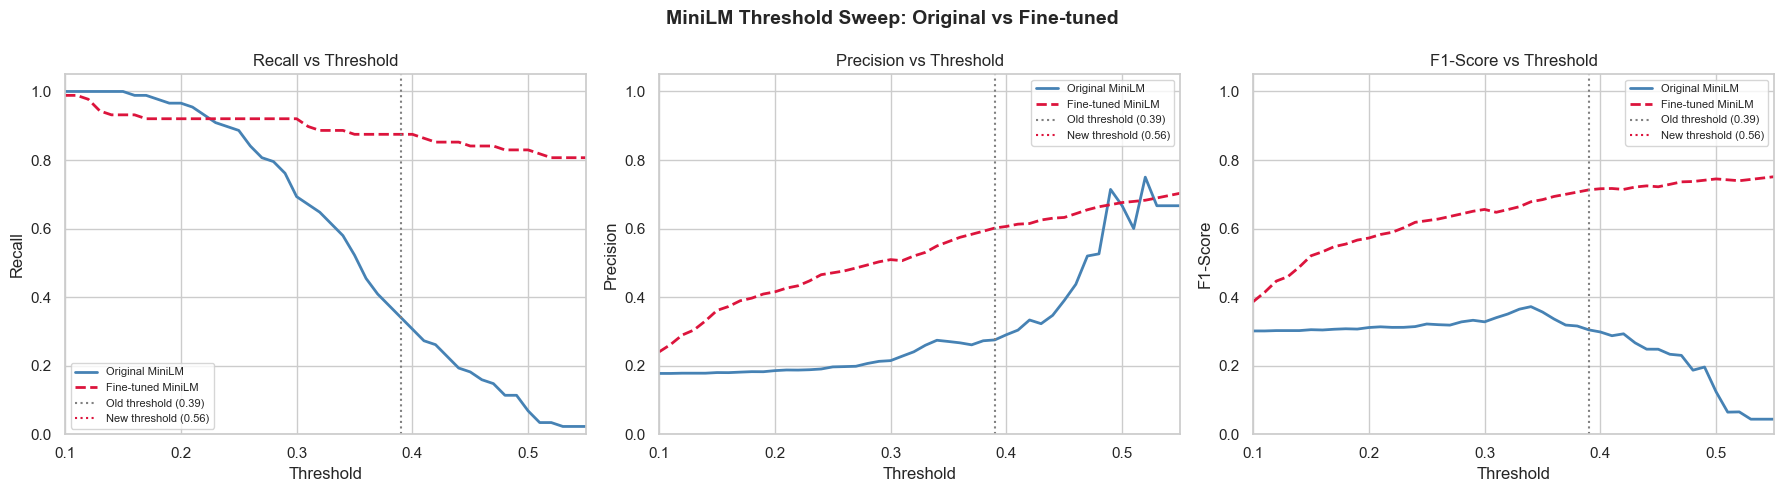

Plot saved → outputs/minilm_threshold_sweep.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MiniLM Threshold Sweep: Original vs Fine-tuned', fontsize=14, fontweight='bold')

for ax_idx, (metric, label) in enumerate([('recall','Recall'), ('precision','Precision'), ('f1','F1-Score')]):
    axes[ax_idx].plot(df_sweep_orig['threshold'], df_sweep_orig[metric],
                      label='Original MiniLM', color='steelblue', linewidth=2)
    axes[ax_idx].plot(df_sweep_ft['threshold'],  df_sweep_ft[metric],
                      label='Fine-tuned MiniLM', color='crimson', linewidth=2, linestyle='--')
    axes[ax_idx].axvline(0.39, color='gray', linestyle=':', linewidth=1.5,
                         label='Old threshold (0.39)')
    axes[ax_idx].axvline(best_ft['threshold'], color='crimson', linestyle=':',
                         linewidth=1.5, label=f'New threshold ({best_ft["threshold"]:.2f})')
    axes[ax_idx].set_xlabel('Threshold')
    axes[ax_idx].set_ylabel(label)
    axes[ax_idx].set_title(f'{label} vs Threshold')
    axes[ax_idx].legend(fontsize=8)
    axes[ax_idx].set_xlim(0.10, 0.55)
    axes[ax_idx].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


---
## Integration — Updated Pipeline Summary

The fine-tuned models are saved to:
- `models/deberta_food_safety/` — binary hazard classifier (replaces zero-shot Stage 2)
- `models/minilm_food_safety/`  — improved bi-encoder (replaces original Stage 1)

**How to use in `food_safety_simple.ipynb`:**

### Stage 1 change (Section 2)
Replace `SentenceTransformer('all-MiniLM-L6-v2')` with `SentenceTransformer('models/minilm_food_safety')`.  
Use the threshold recommended by the sweep above (`best_ft["threshold"]`).

### Stage 2 change (Section 3)
Replace the zero-shot DeBERTa pipeline with:
```python
from transformers import pipeline as hf_pipeline
ft_deberta = hf_pipeline('text-classification', model='models/deberta_food_safety',
                          tokenizer='models/deberta_food_safety', truncation=True,
                          max_length=256, batch_size=32)
# Predict on candidates:  r['label'] == 'hazard'  →  confirmed hazard
```
> **Note:** The fine-tuned model is binary (hazard / safe). Category labels (Illness, Contamination, etc.) are no longer assigned per review — if you need categories for the product-level assessment, keep the zero-shot model for category assignment only on the binary-confirmed positives.

The cell below runs a quick end-to-end check to confirm both fine-tuned models work correctly.

In [54]:
# ── Quick end-to-end sanity check with both fine-tuned models ─────────
print('=== Sanity Check: Fine-tuned Models ===\n')

sample_hazard = [
    "I got severe food poisoning after eating this. I was vomiting for 2 days.",
    "Found a piece of plastic in the food. Completely unacceptable.",
    "Tastes absolutely horrible, completely inedible. Threw the whole thing away.",
    "My dog had an allergic reaction — turns out there were undisclosed ingredients.",
]
sample_safe = [
    "This is my favorite snack! Great taste and very affordable.",
    "Excellent product, arrived on time and packaging was perfect.",
]

all_samples = sample_hazard + sample_safe

# DeBERTa binary check
print('[ Fine-tuned DeBERTa ]')
deberta_results = ft_pipe(all_samples)
for text, res in zip(all_samples, deberta_results):
    emoji = '✓' if res['label'] == 'hazard' else '○'
    print(f'  {emoji} [{res["label"]:<6} {res["score"]:.2f}]  {text[:80]}')

# MiniLM similarity check
print(f'\n[ Fine-tuned MiniLM  (threshold={best_ft["threshold"]:.2f}) ]')
sample_embs  = ft_minilm.encode(all_samples, convert_to_tensor=True)
probe_embs   = ft_minilm.encode(EVAL_PROBES, convert_to_tensor=True)
sim_scores   = util.cos_sim(sample_embs, probe_embs).max(dim=1).values.cpu().numpy()

for text, score in zip(all_samples, sim_scores):
    flag = '✓' if score >= best_ft['threshold'] else '○'
    print(f'  {flag} [sim={score:.3f}]  {text[:80]}')

print('\nBoth models loaded and working.')

=== Sanity Check: Fine-tuned Models ===

[ Fine-tuned DeBERTa ]
  ✓ [hazard 1.00]  I got severe food poisoning after eating this. I was vomiting for 2 days.
  ✓ [hazard 1.00]  Found a piece of plastic in the food. Completely unacceptable.
  ✓ [hazard 1.00]  Tastes absolutely horrible, completely inedible. Threw the whole thing away.
  ✓ [hazard 1.00]  My dog had an allergic reaction — turns out there were undisclosed ingredients.
  ○ [safe   1.00]  This is my favorite snack! Great taste and very affordable.
  ○ [safe   1.00]  Excellent product, arrived on time and packaging was perfect.

[ Fine-tuned MiniLM  (threshold=0.56) ]
  ✓ [sim=0.836]  I got severe food poisoning after eating this. I was vomiting for 2 days.
  ✓ [sim=0.881]  Found a piece of plastic in the food. Completely unacceptable.
  ✓ [sim=0.946]  Tastes absolutely horrible, completely inedible. Threw the whole thing away.
  ✓ [sim=0.756]  My dog had an allergic reaction — turns out there were undisclosed ingredients.
  ○

---
## Option D — Fine-tune DeBERTa as Multi-class Classifier (6 categories)

Train a second DeBERTa model that predicts the **specific hazard category** instead of just binary hazard/safe.

| Label | Description | Train samples (approx) |
|:---:|---|:---:|
| `quality_defect` | Inedible, terrible taste, broken packaging | ~600 |
| `illness` | Food poisoning, vomiting, gastroenteritis | ~110 |
| `spoilage` | Rotten, expired, mold | ~50 |
| `contamination` | Foreign objects, insects, chemicals | ~30 |
| `allergen` | Undisclosed allergens, allergic reactions | ~30 |
| `safe` | Normal reviews — no hazard | ~4,118 |

> **Note on rare classes:** `spoilage`, `contamination`, and `allergen` have very few training examples.  
> Expect low per-category recall for these. The model will still learn to separate *hazard vs safe* accurately.  
> Category predictions for rare classes should be treated as indicative, not authoritative.

**Architecture:** Same `deberta-v3-small` base, same class-weighted loss, 6-way softmax head.  
**Binary derivation:** `is_hazard = (predicted_label != 'safe')` — gives a free binary prediction from the MC model.  
**Saved to:** `models/deberta_food_safety_mc/`


In [55]:
# ── D.1: Multi-class label config & class-weighted datasets ───────────

MC_LABEL_NAMES = ['quality_defect', 'illness', 'spoilage', 'contamination', 'allergen', 'safe']
MC_LABEL2ID    = {l: i for i, l in enumerate(MC_LABEL_NAMES)}
MC_ID2LABEL    = {i: l for l, i in MC_LABEL2ID.items()}
DEBERTA_MC_OUT = os.path.join(MODELS_DIR, 'deberta_food_safety_mc')
os.makedirs(DEBERTA_MC_OUT, exist_ok=True)

print('Multi-class label mapping:')
for label, idx in MC_LABEL2ID.items():
    total   = int((df_gold['label'] == label).sum())
    n_train = int((df_train['label'] == label).sum())
    print(f'  {idx}: {label:<18}  gold={total:>4}  train={n_train:>4}')

# Class weights per category (inverse frequency, balanced)
mc_labels_train = df_train['label'].map(MC_LABEL2ID).fillna(MC_LABEL2ID['safe']).astype(int).values
cw_mc = compute_class_weight(
    'balanced',
    classes=np.arange(len(MC_LABEL_NAMES)),
    y=mc_labels_train
)
CLASS_WEIGHTS_MC = torch.tensor(cw_mc, dtype=torch.float)
print('\nClass weights (balanced):')
for name, w in zip(MC_LABEL_NAMES, CLASS_WEIGHTS_MC):
    print(f'  {name:<18}  weight={w:.2f}')

# ── Multi-class datasets ──────────────────────────────────────────────
def make_mc_dataset(df, tokenizer, max_length=MAX_LENGTH_DEB):
    texts  = df['Text'].fillna('').str[:max_length * 5].tolist()
    labels = df['label'].map(MC_LABEL2ID).fillna(MC_LABEL2ID['safe']).astype(int).tolist()
    return ReviewDataset(texts, labels, tokenizer, max_length)

train_mc_ds = make_mc_dataset(df_train, tokenizer)
val_mc_ds   = make_mc_dataset(df_val,   tokenizer)
test_mc_ds  = make_mc_dataset(df_test,  tokenizer)

print(f'\nMulti-class datasets:')
print(f'  train_mc_ds : {len(train_mc_ds)}')
print(f'  val_mc_ds   : {len(val_mc_ds)}')
print(f'  test_mc_ds  : {len(test_mc_ds)}')

print(f'\nMulti-class model path : {"EXISTS — skip training" if os.path.exists(os.path.join(DEBERTA_MC_OUT, "config.json")) else "not found — will train"}')


Multi-class label mapping:
  0: quality_defect      gold= 778  train= 621
  1: illness             gold=  59  train=  49
  2: spoilage            gold=  23  train=  20
  3: contamination       gold=  12  train=  10
  4: allergen            gold=  10  train=   6
  5: safe                gold=4118  train=3294

Class weights (balanced):
  quality_defect      weight=1.07
  illness             weight=13.61
  spoilage            weight=33.33
  contamination       weight=66.67
  allergen            weight=111.11
  safe                weight=0.20

Multi-class datasets:
  train_mc_ds : 4000
  val_mc_ds   : 500
  test_mc_ds  : 500

Multi-class model path : not found — will train


In [56]:
# ── D.2: Train / load multi-class DeBERTa ─────────────────────────────

def compute_mc_metrics(eval_pred):
    """Eval metric: uses BINARY-derived F1 (pred != 'safe' → hazard) for best-model selection."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    bin_preds  = (preds  != MC_LABEL2ID['safe']).astype(int)
    bin_labels = (labels != MC_LABEL2ID['safe']).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        bin_labels, bin_preds, average='binary', zero_division=0
    )
    acc = accuracy_score(labels, preds)   # exact 6-way accuracy
    return {
        'accuracy':  round(float(acc), 4),
        'precision': round(float(p),   4),
        'recall':    round(float(r),   4),
        'f1':        round(float(f1),  4),   # binary-derived F1 used for checkpoint selection
    }

if os.path.exists(os.path.join(DEBERTA_MC_OUT, 'config.json')):
    print(f'Multi-class DeBERTa found → loading from {DEBERTA_MC_OUT}')
    mc_model = AutoModelForSequenceClassification.from_pretrained(DEBERTA_MC_OUT)
else:
    print(f'Loading base model for multi-class: {DEBERTA_BASE}')
    mc_model = AutoModelForSequenceClassification.from_pretrained(
        DEBERTA_BASE,
        num_labels=len(MC_LABEL_NAMES),
        id2label=MC_ID2LABEL,
        label2id=MC_LABEL2ID,
        use_safetensors=True,
    )

    mc_training_args = TrainingArguments(
        output_dir                  = DEBERTA_MC_OUT,
        num_train_epochs            = 5,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        learning_rate               = 2e-5,
        warmup_ratio                = 0.10,
        weight_decay                = 0.01,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'f1',    # binary-derived F1
        greater_is_better           = True,
        logging_steps               = 50,
        fp16                        = torch.cuda.is_available(),
        report_to                   = 'none',
        save_total_limit            = 2,
    )

    mc_trainer = WeightedLossTrainer(
        class_weights   = CLASS_WEIGHTS_MC,
        model           = mc_model,
        args            = mc_training_args,
        train_dataset   = train_mc_ds,
        eval_dataset    = val_mc_ds,
        compute_metrics = compute_mc_metrics,
    )

    print('Starting multi-class fine-tuning...')
    print(f'  Labels      : {MC_LABEL_NAMES}')
    print(f'  Epochs      : {mc_training_args.num_train_epochs}')
    print(f'  Batch size  : {mc_training_args.per_device_train_batch_size}')
    print(f'  Device      : {device.upper()}')
    print(f'  FP16        : {mc_training_args.fp16}')
    print()

    mc_trainer.train()
    mc_trainer.save_model(DEBERTA_MC_OUT)
    tokenizer.save_pretrained(DEBERTA_MC_OUT)
    print(f'\nMulti-class model saved → {os.path.abspath(DEBERTA_MC_OUT)}')

n_mc_params = sum(p.numel() for p in mc_model.parameters()) / 1e6
print(f'Parameters: {n_mc_params:.1f}M')


Loading base model for multi-class: microsoft/deberta-v3-small


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting multi-class fine-tuning...
  Labels      : ['quality_defect', 'illness', 'spoilage', 'contamination', 'allergen', 'safe']
  Epochs      : 5
  Batch size  : 16
  Device      : CUDA
  FP16        : True



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.387300,1.413481,0.862000,0.608700,0.795500,0.689700
2,0.910000,1.023769,0.894000,0.669500,0.897700,0.767000
3,0.693500,1.041858,0.924000,0.752300,0.931800,0.832500
4,0.901800,1.212877,0.936000,0.828000,0.875000,0.850800
5,0.656100,1.250555,0.938000,0.846200,0.875000,0.860300



Multi-class model saved → c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\models\deberta_food_safety_mc
Parameters: 141.9M


In [57]:
# ── D.3: Evaluate multi-class model on held-out test set ─────────────

mc_eval_model = AutoModelForSequenceClassification.from_pretrained(DEBERTA_MC_OUT)
mc_eval_model.eval()

mc_eval_trainer = Trainer(model=mc_eval_model, compute_metrics=compute_mc_metrics)
mc_test_output  = mc_eval_trainer.predict(test_mc_ds)
mc_test_preds   = np.argmax(mc_test_output.predictions, axis=-1)
mc_test_labels  = mc_test_output.label_ids

mc_pred_names  = [MC_ID2LABEL[p] for p in mc_test_preds]
mc_label_names = [MC_ID2LABEL[l] for l in mc_test_labels]

print('=== Multi-class DeBERTa — Test Set (held-out 10%) ===\n')
print(classification_report(mc_label_names, mc_pred_names,
                             labels=MC_LABEL_NAMES, zero_division=0))

# ── Binary-derived metrics (pred != 'safe' → is_hazard) ───────────────
bin_preds_mc  = [0 if n == 'safe' else 1 for n in mc_pred_names]
bin_labels_mc = [0 if n == 'safe' else 1 for n in mc_label_names]

p_mc = precision_score(bin_labels_mc, bin_preds_mc, zero_division=0)
r_mc = recall_score   (bin_labels_mc, bin_preds_mc, zero_division=0)
f_mc = f1_score       (bin_labels_mc, bin_preds_mc, zero_division=0)

# Binary dedicated model metrics (from earlier cells)
bin_preds_s   = test_preds.tolist()    if isinstance(test_preds, np.ndarray) else [np.argmax(x) for x in test_output.predictions]
bin_labels_s  = test_labels.tolist()

# Make sure binary preds are still in scope; fall back to recomputing if needed
try:
    p_bin = precision_score(bin_labels_s, bin_preds_s, zero_division=0)
    r_bin = recall_score   (bin_labels_s, bin_preds_s, zero_division=0)
    f_bin = f1_score       (bin_labels_s, bin_preds_s, zero_division=0)
except Exception:
    p_bin = r_bin = f_bin = float('nan')

print('\n=== Binary Comparison: Dedicated Binary Model vs Multi-class (derived) ===\n')
print(f'{"Metric":<12} {"Binary Model":>16} {"MC-derived":>14}  {"Δ (MC-bin)":>12}')
print('-' * 58)
for metric, b, m in [('Precision', p_bin, p_mc), ('Recall', r_bin, r_mc), ('F1-Score', f_bin, f_mc)]:
    delta = m - b if not (np.isnan(b) or np.isnan(m)) else float('nan')
    print(f'{metric:<12} {b:>16.4f} {m:>14.4f}  {delta:>+12.4f}')

print('\nNOTE: Multi-class model is optimised for category assignment.')
print('      The dedicated binary model usually has higher binary F1.')
print('      Use multi-class for category labels, binary for is_hazard filtering.')

# Save MC predictions for the test set
df_mc_eval = df_test[['Id', 'Text', 'label', 'human_is_hazard']].copy()
df_mc_eval['pred_category']  = mc_pred_names
df_mc_eval['pred_is_hazard'] = [0 if n == 'safe' else 1 for n in mc_pred_names]
df_mc_eval['category_correct'] = (df_mc_eval['label'] == df_mc_eval['pred_category'])
df_mc_eval.to_csv('outputs/eval_finetuned_deberta_mc_testset.csv', index=False)
print('\nMC test-set predictions saved → outputs/eval_finetuned_deberta_mc_testset.csv')


=== Multi-class DeBERTa — Test Set (held-out 10%) ===

                precision    recall  f1-score   support

quality_defect       0.77      0.76      0.77        75
       illness       0.71      0.62      0.67         8
      spoilage       0.00      0.00      0.00         1
 contamination       0.00      0.00      0.00         2
      allergen       0.00      0.00      0.00         2
          safe       0.95      0.97      0.96       412

      accuracy                           0.92       500
     macro avg       0.41      0.39      0.40       500
  weighted avg       0.91      0.92      0.91       500


=== Binary Comparison: Dedicated Binary Model vs Multi-class (derived) ===

Metric           Binary Model     MC-derived    Δ (MC-bin)
----------------------------------------------------------
Precision              0.8000         0.8272       +0.0272
Recall                 0.8182         0.7614       -0.0568
F1-Score               0.8090         0.7929       -0.0161

NOTE: Mul

=== Multi-class Confusion Matrix (counts) ===
                quality_defect  illness  spoilage  contamination  allergen  safe
quality_defect              57        1         0              0         0    17
illness                      1        5         0              0         0     2
spoilage                     1        0         0              0         0     0
contamination                1        0         0              0         0     1
allergen                     1        0         0              0         0     1
safe                        13        1         0              0         0   398


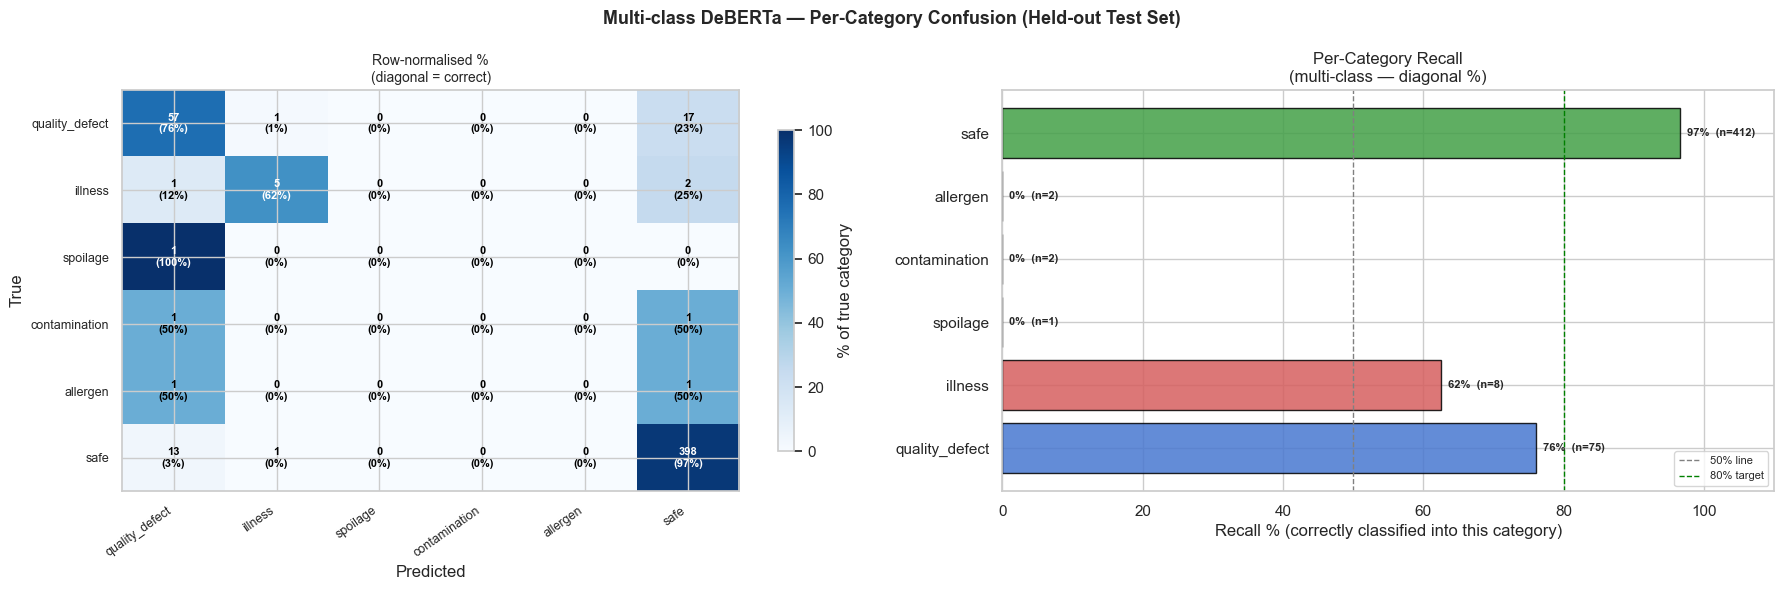

Plot saved → outputs/per_category_confusion_mc.png

=== Summary: Binary vs Multi-class DeBERTa ===
Model                           Precision   Recall       F1
------------------------------------------------------------
Binary DeBERTa (dedicated)         0.8000   0.8182   0.8090
Multi-class DeBERTa (derived)      0.8272   0.7614   0.7929

Use binary model for is_hazard → best binary performance.
Use multi-class model to assign categories to confirmed hazards.


In [ ]:
# ── D.4: Per-category confusion heatmap — multi-class model ──────────

MC_LABEL_COLORS = {
    'quality_defect': '#4878d0',
    'illness':        '#d65f5f',
    'spoilage':       '#8c6d31',
    'contamination':  '#e07b39',
    'allergen':       '#9e4db2',
    'safe':           '#43a047',
}

# Confusion matrix (6×6)
cm_mc = confusion_matrix(mc_label_names, mc_pred_names, labels=MC_LABEL_NAMES)
cm_mc_df = pd.DataFrame(cm_mc, index=MC_LABEL_NAMES, columns=MC_LABEL_NAMES)

# Row-normalised %
row_totals = cm_mc_df.sum(axis=1).replace(0, 1)
cm_mc_pct  = cm_mc_df.div(row_totals, axis=0) * 100

print('=== Multi-class Confusion Matrix (counts) ===')
print(cm_mc_df.to_string())

# ── Visualisation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Multi-class DeBERTa — Per-Category Confusion (Held-out Test Set)',
             fontsize=13, fontweight='bold')

# Left: 6×6 heatmap
ax0 = axes[0]
cmap_mc = plt.cm.Blues
im = ax0.imshow(cm_mc_pct.values, cmap=cmap_mc, vmin=0, vmax=100, aspect='auto')
ax0.set_xticks(range(len(MC_LABEL_NAMES)))
ax0.set_yticks(range(len(MC_LABEL_NAMES)))
ax0.set_xticklabels(MC_LABEL_NAMES, rotation=35, ha='right', fontsize=9)
ax0.set_yticklabels(MC_LABEL_NAMES, fontsize=9)
ax0.set_xlabel('Predicted')
ax0.set_ylabel('True')
ax0.set_title('Row-normalised %\n(diagonal = correct)', fontsize=10)
for i, true_cat in enumerate(MC_LABEL_NAMES):
    for j, pred_cat in enumerate(MC_LABEL_NAMES):
        count = int(cm_mc_df.loc[true_cat, pred_cat])
        pct   = cm_mc_pct.loc[true_cat, pred_cat]
        color = 'white' if pct > 60 else 'black'
        ax0.text(j, i, f'{count}\n({pct:.0f}%)',
                 ha='center', va='center', fontsize=8, fontweight='bold', color=color)
plt.colorbar(im, ax=ax0, label='% of true category', shrink=0.8)

# Right: Per-category recall bar (diagonal / row total)
ax1 = axes[1]
per_cat_recall = [cm_mc_pct.loc[c, c] for c in MC_LABEL_NAMES]
colors_mc      = [MC_LABEL_COLORS.get(c, 'gray') for c in MC_LABEL_NAMES]
bars_mc        = ax1.barh(MC_LABEL_NAMES, per_cat_recall,
                          color=colors_mc, edgecolor='black', alpha=0.85)
ax1.axvline(50,  color='gray',  linestyle='--', linewidth=1, label='50% line')
ax1.axvline(80,  color='green', linestyle='--', linewidth=1, label='80% target')
ax1.set_xlabel('Recall % (correctly classified into this category)')
ax1.set_title('Per-Category Recall\n(multi-class — diagonal %)')
ax1.set_xlim(0, 110)
ax1.legend(fontsize=8)
for bar, val, cat in zip(bars_mc, per_cat_recall, MC_LABEL_NAMES):
    n_total = int(cm_mc_df.loc[cat].sum())
    ax1.text(val + 1, bar.get_y() + bar.get_height() / 2,
             f'{val:.0f}%  (n={n_total})', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Summary ────────────────────────────────────────────────────────────
print('\n=== Summary: Binary vs Multi-class DeBERTa ===')
print(f'{"Model":<30} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 60)
print(f'{"Binary DeBERTa (dedicated)":<30} {p_bin:>10.4f} {r_bin:>8.4f} {f_bin:>8.4f}')
print(f'{"Multi-class DeBERTa (derived)":<30} {p_mc:>10.4f} {r_mc:>8.4f} {f_mc:>8.4f}')
print('\nUse binary model for is_hazard → best binary performance.')
print('Use multi-class model to assign categories to confirmed hazards.')
